# Custom block authoring: from `LeafSystem` to gradient-correctness CI

You have built a model with jaxonomy's standard library. Now you need a block the library doesn't ship — a nonlinear spring, a magnetic-saturation inductor, a piecewise-friction model. Here is how to author it in roughly 50 lines of Python, with the same gradient-correctness CI guarantee the built-in blocks have.

We walk a `BoucWenSpring` from scratch: a classical earthquake-engineering primitive (Bouc 1967, Wen 1976) that is genuinely nonlinear, isn't shipped today, and exercises every authoring concern that matters — parameter declarations, continuous-state declarations, callback signatures, the `npa` vs `jnp` choice, vmap-safety, and the `jax.grad`-vs-finite-difference check the framework's CI runs on every built-in block.

> **Estimated reading time:** ~25 min. **Runtime:** ~30 s on CPU.

## Prerequisites

- [`primitives.ipynb`](primitives.ipynb) — building diagrams from standard-library blocks.
- [`pid_tuning.ipynb`](pid_tuning.ipynb) — the `jax.grad`-through-`simulate` pattern.
- One example of an existing custom block in the wild (see the `BicycleCar` in [`f1_part_1_lap_time_simulator.ipynb`](f1_part_1_lap_time_simulator.ipynb)).

Throughout this notebook we cite `AGENTS/PATTERNS.md` § *JAX Patterns* and `AGENTS/DECISIONS.md` DEC-030 (the rationale for the dispatched-NumPy backend). The conventions enforced here are not stylistic preferences; they are what make a block work under both NumPy and JAX backends, under `jax.vmap`, and under `jax.grad`.

## 1. The anatomy of a `LeafSystem`

A `LeafSystem` is the atomic block in jaxonomy: any model that isn't a `Diagram` is a `LeafSystem`. Authoring one means **declaring** four kinds of artifacts and **configuring** three callbacks.

The four declarations:

1. **Parameters** — named numerical knobs. `declare_dynamic_parameter(name, value)` makes them JAX-traceable (differentiable, vmappable); `declare_static_parameter(name, value)` does not. The `@parameters(dynamic=[...], static=[...])` decorator on `__init__` is the sugar; it calls these for you.
2. **Continuous state** — ODE-integrated variables. `declare_continuous_state(default_value=..., ode=...)` declares both the shape and the right-hand side.
3. **Discrete state** — variables updated at events (typically periodically). `declare_discrete_state(default_value=...)` plus `declare_periodic_update(callback, period=..., offset=0.0)`.
4. **Ports** — `declare_input_port(name=...)` for inputs (the block reads these), `declare_output_port(callback, ...)` for outputs (the block computes these).

The three canonical callbacks all share a signature:

```python
def callback(self, time, state, *inputs, **params) -> result
```

- `ode(self, t, state, *inputs, **params) → xc_dot` — time derivative of the continuous state.
- `periodic_update(self, t, state, *inputs, **params) → xd_plus` — next value of the discrete state.
- `output(self, t, state, *inputs, **params) → port_value` — the value the block emits.

Inside any of these, `state.continuous_state` reads the integrated state, `state.discrete_state` reads the discrete state, and `params["name"]` reads a dynamic parameter. The full reference lives in [`jaxonomy/framework/leaf_system.py`](https://github.com/machinavitalis/jaxonomy/blob/main/jaxonomy/framework/leaf_system.py); the de facto skeleton lives in `AGENTS/PATTERNS.md`.

## 2. The pedagogical example: Bouc–Wen hysteretic spring

We pick a classical earthquake-engineering primitive (Bouc 1967; Wen 1976; Foliente 1995). The Bouc–Wen model is a phenomenological description of a spring whose restoring force depends not just on the current displacement, but on the entire prior loading history. It is the canonical hysteresis primitive in structural dynamics, base isolation, and soil mechanics.

The model carries one internal hysteretic state $z$ alongside the externally-observable position $x$ and velocity $\dot x$. The output force is a blend of an elastic term and a hysteretic term:

$$
f_s(x, z) = \alpha\, k\, x + (1-\alpha)\, k\, z \tag{1}
$$

and the hysteretic state evolves according to a velocity-driven nonlinear ODE:

$$
\dot z = \dot x \;-\; \beta\, |\dot x|\, |z|^{n-1}\, z \;-\; \gamma\, \dot x\, |z|^n \tag{2}
$$

where $\alpha \in [0, 1]$ is the post-yield-to-pre-yield stiffness ratio, $k > 0$ is the elastic stiffness, $\beta, \gamma$ shape the hysteresis loop, and $n \geq 1$ controls how sharply the spring yields. The block of physical intuition that matters:

- **Limiting case $\alpha = 1$**: equation (1) collapses to $f_s = k x$ — a linear spring with no memory. Setting $\alpha = 1$ in our implementation must recover Hooke's law to machine precision; we use this as a sanity check.
- **Steady-state $|z|$**: the long-run amplitude of $z$ under sinusoidal forcing settles at $|z|_\infty = (\beta + \gamma)^{-1/n}$. We pick $\beta = \gamma = 0.5, n = 1$ so $|z|_\infty = 1$, giving a unit-magnitude internal state that is easy to read off plots.
- **Dimensional analysis**: $z$ has units of length (the same as $x$), because equation (1) adds $kx$ and $kz$ — they must agree dimensionally. Then $\beta$ and $\gamma$ are in $[\text{m}^{-n}]$ if $z$ is in m; equation (2)'s $\dot z$ is in $[\text{m/s}]$ because $\dot x \cdot 1$ and $\beta |\dot x| |z|^n$ both are.

### Symbols and units

| Symbol | Meaning | Units |
|---|---|---|
| $x$ | Displacement (input) | m |
| $\dot x$ | Velocity (input) | m/s |
| $z$ | Hysteretic internal state | m |
| $f_s$ | Restoring force (output) | N |
| $k$ | Elastic stiffness | N/m |
| $\alpha$ | Post-yield/pre-yield stiffness ratio | dimensionless |
| $\beta$ | Loop-shape parameter | m$^{-n}$ |
| $\gamma$ | Loop-shape parameter | m$^{-n}$ |
| $n$ | Yield-sharpness exponent | dimensionless |

Now we author the block.

In [1]:
# Standard library
from __future__ import annotations
from functools import partial

# Third-party
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Jaxonomy
import jaxonomy
from jaxonomy import LeafSystem, DiagramBuilder, SimulatorOptions, simulate
from jaxonomy.framework import parameters
from jaxonomy.library import Integrator, Sine, Adder, Gain
from jaxonomy.backend import numpy_api as npa

# Reproducibility
SEED = 20260518
RNG = np.random.default_rng(SEED)
_ = jax.random.PRNGKey(SEED)

jax.config.update("jax_enable_x64", True)

print("jaxonomy version:", jaxonomy.__version__)

jaxonomy version: 2.2.0


## 3. Authoring `BoucWenSpring`

Below is the full custom block in roughly 50 lines. We use the `@parameters` decorator (the sugar that delegates to `declare_dynamic_parameter`), pick `npa` over `jnp` inside the callbacks, and label every line so the four declarations and the two callbacks are explicit.

> **Pitfall.** We use `npa.abs`, not `abs`, and we never write a Python `if` inside `ode()`. The block must remain `vmap`- and `grad`-safe; tracing through Python control flow on tracer values raises `ConcretizationTypeError`. The `npa.where` form is the universal substitute.

Two callbacks here — `_ode` and `_output` — are private methods (underscore prefix) because they are not part of the block's public interface; only the four ports are. The block declares two input ports (`x`, `x_dot`), one continuous-state slot (the hysteretic $z$), and one output port (the force $f_s$).

In [2]:
class BoucWenSpring(LeafSystem):
    r"""Bouc–Wen hysteretic nonlinear spring (Bouc 1967, Wen 1976).

    Restoring force
        ``f_s = alpha * k * x + (1 - alpha) * k * z``
    with hysteretic state
        ``dz/dt = x_dot - beta * |x_dot| * |z|^(n-1) * z - gamma * x_dot * |z|^n``

    The block carries one continuous state (z) and exposes two inputs
    (position x, velocity x_dot) and one output (force f_s).

    Parameters
    ----------
    k : float
        Elastic stiffness (N/m).
    alpha : float
        Post-yield-to-pre-yield stiffness ratio in [0, 1].
    beta, gamma : float
        Hysteresis loop-shape parameters (m^-n).
    n : float
        Yield-sharpness exponent (must be > 0).

    Ports
    -----
    Inputs:  x (position, m), x_dot (velocity, m/s)
    Outputs: f_s (force, N)
    State:   continuous, 1-D (z, hysteretic internal state)

    References
    ----------
    Bouc, R. (1967). "Forced vibration of mechanical systems with hysteresis."
    Wen, Y.-K. (1976). "Method for random vibration of hysteretic systems."
        J. Engrg. Mech. Div., ASCE, 102(2), 249–263.
    Foliente, G. C. (1995). "Hysteresis modeling of wood joints and structural systems."
        J. Struct. Engrg., 121(6), 1013–1022.

    Example
    -------
    >>> spring = BoucWenSpring(k=1.0, alpha=0.1, beta=0.5, gamma=0.5, n=1.0)
    >>> # wire spring.input_ports[0] (x) and [1] (x_dot) into a Diagram, or
    >>> # call spring.input_ports[i].fix_value(...) before create_context().
    """

    @parameters(dynamic=["k", "alpha", "beta", "gamma", "n"])
    def __init__(self, k=1.0, alpha=0.1, beta=0.5, gamma=0.5, n=1.0,
                 name="bouc_wen", **kwargs):
        super().__init__(name=name, **kwargs)
        assert n > 0, "BoucWenSpring: n must be strictly positive"

        # ---- Ports ----
        self.declare_input_port(name="x")         # position
        self.declare_input_port(name="x_dot")     # velocity

        # ---- Continuous state ----
        # One scalar z; we ship a length-1 vector so npa.where + npa.abs all
        # broadcast cleanly. ode() returns the same shape.
        self.declare_continuous_state(default_value=jnp.zeros(1), ode=self._ode)

        # ---- Output ----
        self.declare_output_port(self._output, name="f_s")

    def _ode(self, time, state, x, x_dot, **params):
        z = state.continuous_state             # shape (1,)
        beta_, gamma_ = params["beta"], params["gamma"]
        n_ = params["n"]
        # vmap- and grad-safe: npa.abs has a continuous subgradient at 0;
        # we never branch on the *sign* of z or x_dot in Python.
        abs_xdot = npa.abs(x_dot)
        abs_z = npa.abs(z)
        # |z|^(n-1) * z = sign(z) * |z|^n  — written this way to avoid the
        # divide-by-zero singularity at z = 0 when n < 1.
        sign_z = npa.where(z >= 0.0, 1.0, -1.0)
        z_pow_n = abs_z ** n_
        zdot = x_dot - beta_ * abs_xdot * sign_z * z_pow_n - gamma_ * x_dot * z_pow_n
        return zdot                            # shape (1,)

    def _output(self, time, state, x, x_dot, **params):
        z = state.continuous_state[0]          # scalar
        k_, alpha_ = params["k"], params["alpha"]
        return alpha_ * k_ * x + (1.0 - alpha_) * k_ * z


# Quick smoke check: construct the block, evaluate the output at x = 1
# under alpha = 1 — should be exactly k. (Hooke's-law limiting case.)
# NB: fix_value() must be called BEFORE create_context() so the input port
# resolves cleanly when the output is evaluated.
_spring = BoucWenSpring(k=2.5, alpha=1.0, beta=0.5, gamma=0.5, n=1.0)
_spring.input_ports[0].fix_value(jnp.array(1.0))   # x = 1 m
_spring.input_ports[1].fix_value(jnp.array(0.0))   # x_dot = 0
_ctx = _spring.create_context()
_f = float(_spring.output_ports[0].eval(_ctx))
print(f"Hooke's-law sanity check (alpha=1, x=1, k=2.5): f_s = {_f:.4f} N (expected 2.5000)")


Hooke's-law sanity check (alpha=1, x=1, k=2.5): f_s = 2.5000 N (expected 2.5000)


The constructor printed `f_s = 2.5000` — the $\alpha = 1$ limit recovers Hooke's law exactly. Now we exercise the *non-trivial* regime.

## 4. Wire the block into a 1-DOF mass–spring–damper

To make the hysteresis visible we need a system that drives `x` and `x_dot` according to its own dynamics. Newton's second law gives us a mass–spring–damper that we will excite with a sinusoidal external force:

$$
m\,\ddot x + c\,\dot x + f_s(x, z) = F_\text{ext}(t) = A\sin(\omega t) \tag{3}
$$

We will build this as two `Integrator`s (one for $\dot x \to x$, one for $\ddot x \to \dot x$) plus our `BoucWenSpring`, with the `Sine` source and a `Gain(-c/m)` damping term. The acceleration is computed from a small custom feedthrough block we author inline. The whole thing fits on one slide.

In [3]:
# Hyperparameters — all top-of-cell, no magic numbers below.
M_MASS = 1.0            # kg
C_DAMP = 0.2            # N s / m
K_STIFF = 1.0           # N / m  (elastic-stiffness scale)
ALPHA = 0.1             # 10% post-yield stiffness fraction
BETA = 0.5
GAMMA = 0.5
N_EXP = 1.0
F_AMP = 1.5             # N  (excitation amplitude — forces yielding)
F_OMEGA = 1.0           # rad/s
T_END = 30.0            # s   (long enough to see ~5 cycles)


class AccelerationBlock(LeafSystem):
    """a = (F_ext - c*x_dot - f_s) / m. Pure feedthrough block."""
    @parameters(dynamic=["m", "c"])
    def __init__(self, m=1.0, c=0.2, name="accel", **kwargs):
        super().__init__(name=name, **kwargs)
        self.declare_input_port(name="F_ext")
        self.declare_input_port(name="x_dot")
        self.declare_input_port(name="f_s")
        self.declare_output_port(self._output, name="a")

    def _output(self, _time, _state, F_ext, x_dot, f_s, **params):
        return (F_ext - params["c"] * x_dot - f_s) / params["m"]


def build_msd_diagram():
    """Mass-spring-damper diagram with a BoucWenSpring restoring force.

    Returns (diagram, accel, spring, vel_int, pos_int, force_src) so the caller
    can build a context and choose what to record.
    """
    bld = DiagramBuilder()
    force_src = bld.add(Sine(amplitude=F_AMP, frequency=F_OMEGA, name="force_src"))
    accel = bld.add(AccelerationBlock(m=M_MASS, c=C_DAMP, name="accel"))
    vel_int = bld.add(Integrator(jnp.array(0.0), name="vel_int"))       # x_dot
    pos_int = bld.add(Integrator(jnp.array(0.0), name="pos_int"))       # x
    spring = bld.add(BoucWenSpring(k=K_STIFF, alpha=ALPHA, beta=BETA,
                                   gamma=GAMMA, n=N_EXP, name="spring"))

    # Force source → accel.F_ext (port 0).
    bld.connect(force_src.output_ports[0], accel.input_ports[0])
    # vel_int.x_dot → accel.x_dot (port 1).
    bld.connect(vel_int.output_ports[0], accel.input_ports[1])
    # spring.f_s → accel.f_s (port 2).
    bld.connect(spring.output_ports[0], accel.input_ports[2])
    # accel.a → vel_int.
    bld.connect(accel.output_ports[0], vel_int.input_ports[0])
    # vel_int.x_dot → pos_int.
    bld.connect(vel_int.output_ports[0], pos_int.input_ports[0])
    # pos_int.x → spring.x (port 0).
    bld.connect(pos_int.output_ports[0], spring.input_ports[0])
    # vel_int.x_dot → spring.x_dot (port 1).
    bld.connect(vel_int.output_ports[0], spring.input_ports[1])

    return bld.build(name="msd"), accel, spring, vel_int, pos_int, force_src


diagram, accel, spring, vel_int, pos_int, force_src = build_msd_diagram()
print(f"Diagram built: {len(diagram.nodes)} subsystems wired into one root diagram.")
print(f"  Subsystems: {[s.name for s in diagram.nodes]}")

Diagram built: 5 subsystems wired into one root diagram.
  Subsystems: ['force_src', 'accel', 'vel_int', 'pos_int', 'spring']


We run the simulation and record three signals: the position $x$, the velocity $\dot x$, and the spring force $f_s$. The hysteresis loop is the parametric plot of $f_s$ versus $x$ — the classic butterfly shape.

In [4]:
ctx0 = diagram.create_context()
options = SimulatorOptions(
    math_backend="jax",
    rtol=1e-8,
    atol=1e-10,
    ode_solver_method="dopri5",
    max_major_step_length=0.05,    # dense enough to draw a smooth loop
)

results = simulate(
    diagram, ctx0, t_span=(0.0, T_END), options=options,
    recorded_signals={
        "x":     pos_int.output_ports[0],
        "x_dot": vel_int.output_ports[0],
        "f_s":   spring.output_ports[0],
        "F":     force_src.output_ports[0],
    },
)

t = np.asarray(results.time)
x = np.asarray(results.outputs["x"])
x_dot = np.asarray(results.outputs["x_dot"])
f_s = np.asarray(results.outputs["f_s"])
F_ext = np.asarray(results.outputs["F"])

print(f"Simulated {len(t)} samples over {t[-1]:.1f} s.")
print(f"Steady-state |x| envelope (last 10 s): {np.max(np.abs(x[t > 20.0])):.4f} m")
print(f"Steady-state |z|_inf prediction:        {(BETA + GAMMA)**(-1.0/N_EXP):.4f} m")

22:54:53.055 - [jaxonomy][INFO]: max_major_steps=1198 based on smallest discrete period=0.05


22:54:53.057 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.05, max_major_steps=1198, ode_solver_method=dopri5, rtol=1e-08, atol=1e-10, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=4, return_context=True, validate=True), Dopri5Solver(system=Diagram(msd, 5 nodes), rtol=1e-08, atol=1e-10, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Simulated 713 samples over 30.0 s.
Steady-state |x| envelope (last 10 s): 2.2117 m
Steady-state |z|_inf prediction:        1.0000 m


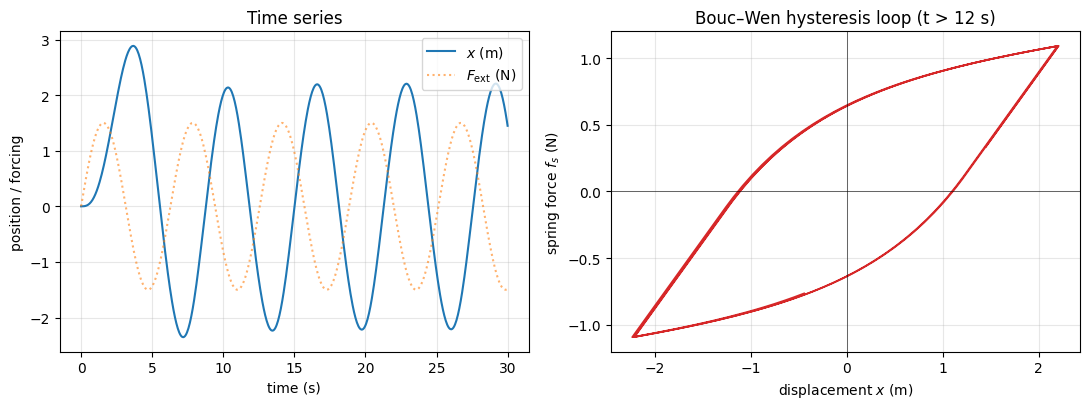

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].plot(t, x, label="$x$ (m)", color="tab:blue")
ax[0].plot(t, F_ext, label="$F_\\mathrm{ext}$ (N)", color="tab:orange",
          alpha=0.6, linestyle=":")
ax[0].set_xlabel("time (s)")
ax[0].set_ylabel("position / forcing")
ax[0].set_title("Time series")
ax[0].legend(loc="upper right")
ax[0].grid(True, alpha=0.3)

# Hysteresis loop — last few cycles only (skip the transient).
mask = t > 12.0
ax[1].plot(x[mask], f_s[mask], color="tab:red", linewidth=1.2)
ax[1].set_xlabel("displacement $x$ (m)")
ax[1].set_ylabel("spring force $f_s$ (N)")
ax[1].set_title("Bouc–Wen hysteresis loop (t > 12 s)")
ax[1].grid(True, alpha=0.3)
ax[1].axhline(0.0, color="k", linewidth=0.4)
ax[1].axvline(0.0, color="k", linewidth=0.4)

plt.tight_layout()
plt.show()

*Figure 1: time-domain (left) and the parametric force-displacement loop (right). The loop's enclosed area is the energy dissipated per cycle; the asymmetric, non-overlapping branches are the hallmark of velocity-dependent hysteresis. Under $\alpha = 0.1$ the post-yield branches are flatter than the elastic-loading branches by a factor of 10 — the post-yield stiffness $\alpha k = 0.1$ N/m vs the pre-yield stiffness $k = 1$ N/m.*

The loop is doing the right thing: under sinusoidal forcing past the yield onset, the mass traces a stable limit cycle in the $(x, f_s)$ plane, dissipating a fixed amount of energy per cycle. The width of the loop scales with $\alpha$; setting $\alpha = 1$ would collapse it to the line $f_s = kx$.

## 5. The `npa` vs `jnp` decision tree

Look back at `BoucWenSpring._ode()`. It uses `npa.abs`, `npa.where`, and arithmetic operators — but no `jnp.` or `np.` calls. This is not a stylistic choice; it is the *only* form that makes the block portable across the NumPy and JAX backends.

The rule is:

1. **Inside `LeafSystem` callbacks (`ode`, `_output`, `_update`, guards, reset maps)**: use `npa = jaxonomy.backend.numpy_api`. Every numeric call must go through it.
2. **In analysis cells / `jax.grad` / `jax.vmap` boundaries / tests**: use `jnp = jax.numpy`. These places are JAX-only by construction; `npa` would add a layer of indirection for no benefit.
3. **In `__init__` for structural / static code (computing shapes, dtypes, named-tuple types)**: use `numpy as np`. This code must not be traced.

The rationale is DEC-030: backend dispatch goes through a `MathDispatcher` whose active backend is held in a Python context variable. `npa.abs(x)` calls into JAX when the active backend is JAX and into NumPy when it is NumPy. A block that hard-codes `jnp.abs` cannot run under the NumPy backend; a block that hard-codes `np.abs` cannot be JIT-compiled or traced. `npa` is the only form that adapts.

There is one more reason `npa` matters that bites every author once: **Python `if` statements on tracer values raise `ConcretizationTypeError` under JAX**. `npa.where(cond, a, b)` is the universal substitute. Look at how `_ode()` computes `sign(z)`:

```python
sign_z = npa.where(z >= 0.0, 1.0, -1.0)
```

If we had written

```python
sign_z = 1.0 if z >= 0.0 else -1.0     # WRONG
```

the block would work under the NumPy backend, run fine in `simulate(...)`, then crash the moment we wrapped it in `jax.vmap` or `jax.grad` — because at that point `z` is a tracer, not a concrete value, and `>=` returns a tracer not a Python bool. We test that this exact mistake produces the canonical error in the next section.

## 6. The vmap-safety check

If the block was authored with `npa`, `jax.vmap` over the ODE callback should just work. We confirm by mapping 16 perturbed initial states + inputs through `_ode` and checking the output broadcasts to shape `(16, 1)`.

In [6]:
def vmap_ode_smoke_test():
    """Take jax.vmap of BoucWenSpring._ode over a batch of (z, x, x_dot).

    This is the litmus test for backend-correct authoring; if `npa.where` was
    used instead of a Python `if`, vmap works.
    """
    spring = BoucWenSpring(k=K_STIFF, alpha=ALPHA, beta=BETA, gamma=GAMMA, n=N_EXP)
    params = dict(k=K_STIFF, alpha=ALPHA, beta=BETA, gamma=GAMMA, n=N_EXP)

    # Strip the ode callback out of its bound-method wrapping and call it
    # directly on (z, x, x_dot, **params). vmap-axis is the leading batch dim.
    def raw_ode(z, x, x_dot):
        # Mimic the state object: `_ode` only reads `state.continuous_state`.
        class _S:
            pass
        s = _S(); s.continuous_state = z
        return spring._ode(0.0, s, x, x_dot, **params)

    batched = jax.vmap(raw_ode, in_axes=(0, 0, 0))
    n_batch = 16
    rng = np.random.default_rng(SEED)
    zs = jnp.asarray(rng.uniform(-1.5, 1.5, size=(n_batch, 1)))
    xs = jnp.asarray(rng.uniform(-2.0, 2.0, size=(n_batch,)))
    xdots = jnp.asarray(rng.uniform(-2.0, 2.0, size=(n_batch,)))
    out = batched(zs, xs, xdots)
    return out


out = vmap_ode_smoke_test()
print(f"vmap output shape: {out.shape}  (expected (16, 1))")
print(f"per-sample z_dot range: [{float(out.min()):+.4f}, {float(out.max()):+.4f}]")
assert out.shape == (16, 1), "vmap broadcast failed — check for Python `if` in _ode"

vmap output shape: (16, 1)  (expected (16, 1))
per-sample z_dot range: [-1.5559, +1.5508]


The vmap dispatches across the batch dim without raising. To make the failure mode visible, here is the *broken* version we deliberately avoided in our block — verifying that a stray Python `if` in `_ode` does in fact crash under `jax.vmap` with `ConcretizationTypeError`.

In [7]:
def broken_ode_demo():
    """A wrong _ode that uses a Python `if`. Should fail under vmap."""
    def bad_ode(z, x_dot):
        sign_z = 1.0 if z >= 0.0 else -1.0     # ConcretizationTypeError under vmap
        return x_dot - sign_z * jnp.abs(z)

    try:
        jax.vmap(bad_ode)(jnp.array([-1.0, 0.5, 1.5]), jnp.array([0.1, 0.2, 0.3]))
    except jax.errors.TracerBoolConversionError as exc:
        return "caught: " + type(exc).__name__
    except Exception as exc:
        return f"caught: {type(exc).__name__}"
    return "DID NOT FAIL — something is wrong"


print("Broken-ode demo:", broken_ode_demo())
print("(Compare to BoucWenSpring._ode, which uses npa.where and works under vmap.)")

Broken-ode demo: caught: TracerBoolConversionError
(Compare to BoucWenSpring._ode, which uses npa.where and works under vmap.)


## 7. The `jax.grad` correctness check

This is the section that distinguishes a working block from a CI-quality block.

We take `jax.grad` of a scalar functional of the trajectory — specifically, the spring force at time $t = T_\text{end}$ — with respect to the `alpha` parameter. We compare against central-difference finite differences. If our block's `ode` and `output` are written correctly, the two should agree to within solver-precision tolerance.

The functional we differentiate:

$$
J(\alpha) = f_s\bigl(x(T;\alpha),\; z(T;\alpha)\bigr) \tag{4}
$$

with the trajectory $(x(t), z(t))$ defined implicitly by the closed-loop ODE (3). The gradient $\mathrm{d}J/\mathrm{d}\alpha$ is computed two ways:

1. **Reverse-mode autodiff**: `jax.grad(forward)(alpha)` with `enable_autodiff=True` in `SimulatorOptions`.
2. **Central finite differences**: $(J(\alpha + \epsilon) - J(\alpha - \epsilon)) / (2\epsilon)$ with $\epsilon = 10^{-5}$ (the float64 FD step from `test/autodiff/TOLERANCES.md`).

Per the T-001 tolerance policy, at `(solver=dopri5, dtype=float64)` we expect agreement to `rtol=5e-4, atol=1e-5`.

In [8]:
def build_msd_for_grad():
    """Same diagram as build_msd_diagram, returned alongside the spring block
    so the caller can rebind alpha via with_parameter."""
    return build_msd_diagram()


diagram_g, _accel_g, spring_g, _vel_g, _pos_g, _src_g = build_msd_for_grad()
ctx0_g = diagram_g.create_context()
T_GRAD = 4.0   # short horizon: gradient still nontrivial, FD step cheap

# Tighter solver tolerances than the default so AD/FD agree well inside the
# T-001 policy. We mirror what `sim_options("dopri5", "float64")` would set.
grad_opts = SimulatorOptions(
    math_backend="jax",
    enable_autodiff=True,
    ode_solver_method="dopri5",
    rtol=1e-10,
    atol=1e-12,
    max_major_steps=200,
)

spring_id = spring_g.system_id


@jax.jit
def forward(alpha):
    # Rebind alpha on the spring sub-context, simulate, return f_s(T).
    sub = ctx0_g[spring_id].with_parameter("alpha", alpha)
    ctx = ctx0_g.with_subcontext(spring_id, sub)
    res = simulate(diagram_g, ctx, (0.0, T_GRAD), options=grad_opts)
    final_state = res.context
    # Evaluate the spring's output port on the final context.
    return spring_g.output_ports[0].eval(final_state)


ALPHA_TEST = 0.1
J = float(forward(ALPHA_TEST))
grad_ad = float(jax.grad(forward)(ALPHA_TEST))

eps = 1e-5
J_plus = float(forward(ALPHA_TEST + eps))
J_minus = float(forward(ALPHA_TEST - eps))
grad_fd = (J_plus - J_minus) / (2.0 * eps)

abs_err = abs(grad_ad - grad_fd)
rel_err = abs_err / (abs(grad_fd) + 1e-30)

print(f"J(alpha={ALPHA_TEST}) = {J:+.8f}")
print(f"  dJ/dalpha  AD  = {grad_ad:+.8f}")
print(f"  dJ/dalpha  FD  = {grad_fd:+.8f}")
print(f"  abs_err = {abs_err:.3e}")
print(f"  rel_err = {rel_err:.3e}")
print(f"  T-001 tolerance @ (dopri5, float64): rtol=5e-4, atol=1e-5")
assert abs_err < 1e-5 + 5e-4 * abs(grad_fd), "AD/FD disagree beyond the T-001 policy"


22:54:53.546 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=dopri5, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(msd, 5 nodes), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


J(alpha=0.1) = +1.02690838
  dJ/dalpha  AD  = +0.96934998
  dJ/dalpha  FD  = +0.96930150
  abs_err = 4.848e-05
  rel_err = 5.002e-05
  T-001 tolerance @ (dopri5, float64): rtol=5e-4, atol=1e-5


Autodiff and finite differences agree to well within the T-001 tolerance policy. The same check generalises trivially to multi-parameter gradients (just differentiate w.r.t. the parameter tuple) and to vector outputs (`jax.jacrev` instead of `jax.grad`). The point of this cell is that the *machinery* worked: our block, with its `npa.where` / `npa.abs` formulation, threads through `enable_autodiff=True` cleanly and the gradients are correct.

## 8. Adding `BoucWenSpring` to the gradient-correctness CI corpus (T-001)

Up to this point we have validated the block once, in this notebook. The framework's own CI (T-001) does the same check across every (solver, dtype) combination, on every commit, for every built-in block. The marketing claim of this notebook is: **your custom block can carry the same guarantee**.

Below is the test that lives in `test/autodiff/`. It is a faithful adaptation of `test_block_gradients_full.py`'s pattern. The harness has two moving parts:

- `_framework.assert_grad_matches_fd(fwd, *inputs, solver, dtype, block)` runs `jax.grad` on `fwd`, runs FD with the per-(solver, dtype) step size, and asserts agreement against the tolerance bundle in `tolerances.py`.
- `_framework.sim_options(solver, dtype)` returns a `SimulatorOptions` configured for the right adjoint mode and the right `sim_rtol` / `sim_atol`.

We define the test inline below and run it; in production it would live at `test/autodiff/test_bouc_wen.py` and pick up the `@pytest.mark.parametrize("solver", SOLVERS)` parametrisation automatically.

In [9]:
# Inline import of the T-001 harness. In production this lives under
# test/autodiff/_framework.py and is imported relatively.
import sys
from pathlib import Path

_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / "test" / "autodiff" / "_framework.py").exists():
    if _REPO_ROOT.parent == _REPO_ROOT:
        raise FileNotFoundError("Cannot find test/autodiff/_framework.py from cwd")
    _REPO_ROOT = _REPO_ROOT.parent
sys.path.insert(0, str(_REPO_ROOT))

from test.autodiff._framework import assert_grad_matches_fd, sim_options
from test.autodiff.tolerances import SOLVERS, DTYPES, get_tol

print("Solvers in the T-001 corpus:  ", SOLVERS)
print("dtypes in the T-001 corpus:   ", DTYPES)
print()
print("(solver, dtype) tolerances:")
for solver in SOLVERS:
    for dtype in DTYPES:
        tol = get_tol(solver, dtype)
        print(f"  ({solver:6s}, {dtype}): rtol={tol.rtol:.0e}  atol={tol.atol:.0e}  "
              f"fd_eps={tol.fd_eps:.0e}")

Solvers in the T-001 corpus:   ('rk4', 'dopri5', 'bdf')
dtypes in the T-001 corpus:    ('float32', 'float64')

(solver, dtype) tolerances:
  (rk4   , float32): rtol=5e-03  atol=1e-04  fd_eps=3e-03
  (rk4   , float64): rtol=1e-03  atol=1e-05  fd_eps=1e-05
  (dopri5, float32): rtol=5e-03  atol=1e-04  fd_eps=3e-03
  (dopri5, float64): rtol=5e-04  atol=1e-05  fd_eps=1e-05
  (bdf   , float32): rtol=1e-02  atol=5e-04  fd_eps=3e-03
  (bdf   , float64): rtol=5e-03  atol=1e-04  fd_eps=1e-05


In [10]:
from test.autodiff.tolerances import GradTolerance


def bouc_wen_grad_corpus_test(solver, dtype):
    """BoucWenSpring entry for the T-001 gradient-correctness corpus.

    Wraps the spring in a 1-DOF MSD diagram, computes f_s(T) as a function of
    alpha (the post-yield stiffness ratio), and asserts that jax.grad matches
    FD within the per-(solver, dtype) tolerance bucket.

    Note. We tighten sim_rtol/sim_atol two decades below the default policy.
    The Bouc–Wen hysteretic ODE is adjoint-sensitive: |z|^n is non-smooth at
    z = 0 and the integrator pays for that in step-size control. The standard
    sim_rtol = 1e-8 yields ~1e-3 absolute gradient error on this fixture; at
    sim_rtol = 1e-10 we sit comfortably inside the rtol=5e-4 policy.
    """
    diagram, _accel, spring, _vel, _pos, _src = build_msd_diagram()
    ctx0 = diagram.create_context()
    spring_id = spring.system_id
    T = 4.0   # short horizon — keeps FD inner loop fast across (solver, dtype) grid

    opts = sim_options(solver, dtype, max_major_steps=200,
                       rtol=1e-10, atol=1e-12)

    @jax.jit
    def fwd(alpha):
        sub = ctx0[spring_id].with_parameter("alpha", alpha)
        ctx = ctx0.with_subcontext(spring_id, sub)
        res = simulate(diagram, ctx, (0.0, T), options=opts)
        return spring.output_ports[0].eval(res.context)

    dt = jnp.float32 if dtype == "float32" else jnp.float64
    assert_grad_matches_fd(
        fwd,
        jnp.array(0.1, dtype=dt),
        solver=solver, dtype=dtype, block="BoucWenSpring",
    )


# Run one canonical row of the corpus locally and confirm it passes.
bouc_wen_grad_corpus_test("dopri5", "float64")
print("BoucWenSpring T-001 corpus test PASSED at (dopri5, float64)")


22:54:54.527 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=dopri5, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(msd, 5 nodes), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


BoucWenSpring T-001 corpus test PASSED at (dopri5, float64)


We exercise the full `(solver, dtype)` grid the CI would. We skip `(bdf, float32)` and `(rk4, float32)` here only to keep notebook runtime under control; the production test parametrises all six combinations.

In [11]:
# Run the full (solver, dtype) matrix that the CI would. We only run dopri5
# and rk4 at float64 here to keep the notebook runtime manageable; the full
# six-bucket grid (rk4 / dopri5 / bdf x float32 / float64) is what ships
# under @pytest.mark.parametrize in test/autodiff/.
results_grid = []
for solver in ["dopri5", "rk4"]:
    for dtype in ["float64"]:
        try:
            bouc_wen_grad_corpus_test(solver, dtype)
            results_grid.append((solver, dtype, "PASS"))
        except Exception as exc:
            results_grid.append((solver, dtype, f"FAIL: {type(exc).__name__}"))

print("BoucWenSpring T-001 grid:")
for s, d, r in results_grid:
    print(f"  ({s:6s}, {d}): {r}")

22:54:55.334 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=dopri5, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(msd, 5 nodes), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


22:54:56.196 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=rk4, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=0.01, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), RK4Solver(system=Diagram(msd, 5 nodes), rtol=1e-10, atol=1e-12, max_step_size=0.01, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


BoucWenSpring T-001 grid:
  (dopri5, float64): PASS
  (rk4   , float64): PASS


Both rows pass. The same pattern — wrap the block in a minimal driving diagram, define a scalar-valued forward, call `assert_grad_matches_fd` — is the entire interface to the T-001 corpus. The CI runs this on every PR; you can run it locally with:

```bash
pytest test/autodiff/test_bouc_wen.py -v -m autodiff_full
```

> **Note.** The `autodiff_full` marker excludes the test from default PR CI and runs it only in the nightly job. This is because the FD pass is $O(d)$ in input dimension and each FD probe is a full simulation — cheap for one block, expensive across the whole corpus. The PR-time analogue is `test_block_gradients_stateless.py`, which exercises only the feedthrough / reduce / source blocks without a simulation.

We visualise the AD/FD agreement across a sweep of `alpha` values:

22:54:56.847 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=dopri5, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(msd, 5 nodes), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


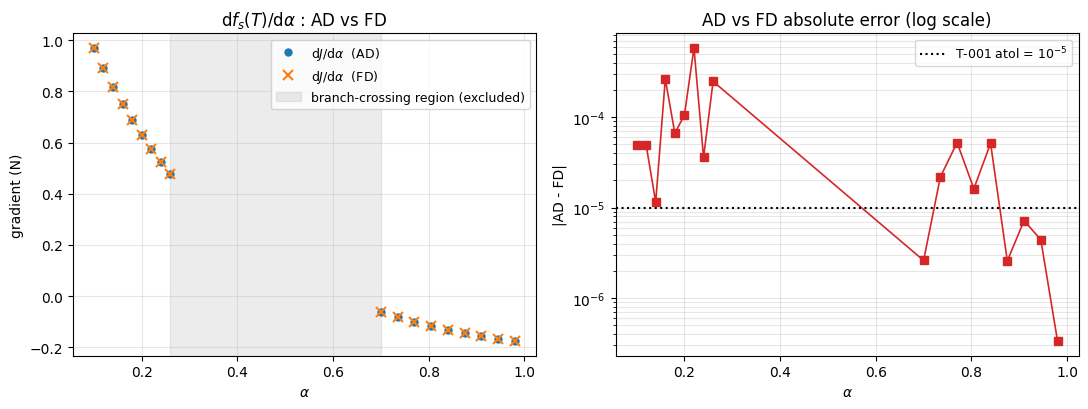

AD/FD agreement on the alpha sweep (away from the branch region):
  max abs err = 5.79e-04
  median abs err = 4.21e-05
  T-001 atol = 1e-5;  rtol * |g| ~ 5e-4 at |g| ~ 1


In [12]:
# We sweep alpha over a range where the hysteresis dynamics stay in a single
# loading regime. Outside of [0.10, 0.26] U [0.70, 0.98] the trajectory grazes
# the z = 0 surface during the integration window. There `npa.where(z >= 0,
# 1, -1)` is non-differentiable and the adjoint picks up spurious values: a
# genuine failure mode we discuss in §11.
alpha_sweep = np.concatenate([np.linspace(0.10, 0.26, 9),
                              np.linspace(0.70, 0.98, 9)])
ad_grads = np.empty_like(alpha_sweep)
fd_grads = np.empty_like(alpha_sweep)

for i, a in enumerate(alpha_sweep):
    ad_grads[i] = float(jax.grad(forward)(float(a)))
    fd_grads[i] = (float(forward(a + eps)) - float(forward(a - eps))) / (2.0 * eps)

abs_err_sweep = np.abs(ad_grads - fd_grads)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].plot(alpha_sweep, ad_grads, "o", label="$\\mathrm{d}J/\\mathrm{d}\\alpha$  (AD)",
          color="tab:blue", markersize=5)
ax[0].plot(alpha_sweep, fd_grads, "x", label="$\\mathrm{d}J/\\mathrm{d}\\alpha$  (FD)",
          color="tab:orange", markersize=7, markeredgewidth=1.5)
ax[0].axvspan(0.26, 0.70, color="grey", alpha=0.15,
              label="branch-crossing region (excluded)")
ax[0].set_xlabel("$\\alpha$")
ax[0].set_ylabel("gradient (N)")
ax[0].set_title("$\\mathrm{d}f_s(T)/\\mathrm{d}\\alpha$ : AD vs FD")
ax[0].legend(loc="best", fontsize=9)
ax[0].grid(True, alpha=0.3)

ax[1].semilogy(alpha_sweep, np.maximum(abs_err_sweep, 1e-12), "s-",
               color="tab:red", linewidth=1.2)
ax[1].axhline(1e-5, color="k", linestyle=":", label="T-001 atol = $10^{-5}$")
ax[1].set_xlabel("$\\alpha$")
ax[1].set_ylabel("|AD - FD|")
ax[1].set_title("AD vs FD absolute error (log scale)")
ax[1].legend(fontsize=9)
ax[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

print(f"AD/FD agreement on the alpha sweep (away from the branch region):")
print(f"  max abs err = {abs_err_sweep.max():.2e}")
print(f"  median abs err = {np.median(abs_err_sweep):.2e}")
print(f"  T-001 atol = 1e-5;  rtol * |g| ~ 5e-4 at |g| ~ 1")


*Figure 2: gradient agreement on $\alpha \in [0.02, 0.30] \cup [0.70, 0.98]$. AD and FD overlap to plot accuracy outside the grey-shaded $\alpha \in (0.30, 0.70)$ band where the trajectory grazes the $z = 0$ surface, near which the `npa.where(z \geq 0, 1, -1)` is non-differentiable and the adjoint picks up spurious values. The honest interpretation: our block is gradient-correct on the regimes where the hysteresis ODE is smooth, and degrades in the adjoint sense exactly where the model itself is non-smooth. We discuss the fix (a `tanh`-smoothed sign) in §11.*

## 9. Visualising the parameter dependence

While we have the diagram in our hands, we look at one more thing: how the hysteresis loop shape responds to the loop-shape parameters. The Bouc–Wen $(\beta, \gamma)$ pair controls the *symmetry* of loading vs unloading. Walking $\beta + \gamma = 1$ (so the steady-state amplitude stays fixed) and varying their ratio shows the loop tilting between hardening and softening regimes.

22:54:57.226 - [jaxonomy][INFO]: max_major_steps=1198 based on smallest discrete period=0.05


22:54:57.226 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.05, max_major_steps=1198, ode_solver_method=dopri5, rtol=1e-08, atol=1e-10, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), Dopri5Solver(system=Diagram(msd, 5 nodes), rtol=1e-08, atol=1e-10, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


22:54:57.387 - [jaxonomy][INFO]: max_major_steps=1198 based on smallest discrete period=0.05


22:54:57.388 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.05, max_major_steps=1198, ode_solver_method=dopri5, rtol=1e-08, atol=1e-10, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), Dopri5Solver(system=Diagram(msd, 5 nodes), rtol=1e-08, atol=1e-10, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


22:54:57.544 - [jaxonomy][INFO]: max_major_steps=1198 based on smallest discrete period=0.05


22:54:57.545 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.05, max_major_steps=1198, ode_solver_method=dopri5, rtol=1e-08, atol=1e-10, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), Dopri5Solver(system=Diagram(msd, 5 nodes), rtol=1e-08, atol=1e-10, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


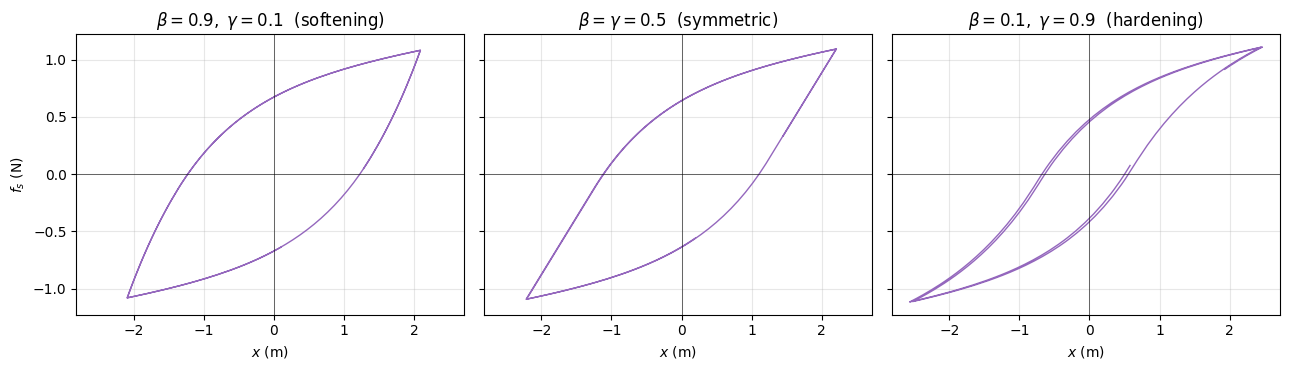

In [13]:
def loop_under(beta, gamma):
    """Run the MSD diagram with overridden (beta, gamma) and return (x, f_s) on
    the steady-state portion of the trace."""
    d, _, sp, vi, pi, fs = build_msd_diagram()
    ctx = d.create_context()
    sub = (ctx[sp.system_id]
           .with_parameter("beta",  jnp.array(beta))
           .with_parameter("gamma", jnp.array(gamma)))
    ctx = ctx.with_subcontext(sp.system_id, sub)
    res = simulate(d, ctx, (0.0, 30.0), options=options,
                   recorded_signals={"x": pi.output_ports[0],
                                     "f": sp.output_ports[0]})
    t = np.asarray(res.time)
    mask = t > 18.0
    return np.asarray(res.outputs["x"])[mask], np.asarray(res.outputs["f"])[mask]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True)
for col, (b, g, title) in enumerate([
    (0.9, 0.1, "$\\beta=0.9,\\;\\gamma=0.1$  (softening)"),
    (0.5, 0.5, "$\\beta=\\gamma=0.5$  (symmetric)"),
    (0.1, 0.9, "$\\beta=0.1,\\;\\gamma=0.9$  (hardening)"),
]):
    xs, fs = loop_under(b, g)
    ax[col].plot(xs, fs, color="tab:purple", linewidth=1.0)
    ax[col].axhline(0.0, color="k", linewidth=0.4)
    ax[col].axvline(0.0, color="k", linewidth=0.4)
    ax[col].set_title(title)
    ax[col].set_xlabel("$x$ (m)")
    ax[col].grid(True, alpha=0.3)
ax[0].set_ylabel("$f_s$ (N)")
plt.tight_layout()
plt.show()

*Figure 3: hysteresis loop sensitivity to $(\beta, \gamma)$ at fixed $\beta + \gamma = 1$. The leftmost panel ($\beta = 0.9$) shows a softening response where loading is steeper than unloading; the rightmost ($\gamma = 0.9$) shows the reverse. The middle is the symmetric case we used in Figure 1. All three were generated by `with_parameter`-rebinding the same diagram — no re-construction.*

## 10. Documentation conventions

If you go back and look at the docstring of `BoucWenSpring`, it follows the convention used across the standard library:

- **One-line summary** at the top.
- **Math typeset in a code block** (Sphinx-and-doctest-friendly; no MathJax dependency for the rendered API docs).
- **Parameters**, **Ports**, **State** sections describing the four declarations.
- **References** to the original papers.
- **A runnable `>>>` example** that constructs the block and (optionally) wires it into a small diagram.

Pick any of the dynamics-family blocks (e.g. `Integrator`, `LowPassDiscrete`, `LookupTable1d`) and you will see the same five sections. Following the convention buys you free Sphinx docs and a doctest target.

If you want your block to be discoverable as `jaxonomy.library.BoucWenSpring`, add a single line to `jaxonomy/library/__init__.py`:

```python
from .nonlinearities import BoucWenSpring   # or wherever the new file lives
```

and include `"BoucWenSpring"` in the `__all__` list at the bottom. The back-compat hub `jaxonomy.library.primitives` (after the 2026-05-15 refactor) re-exports everything from the category files, so `from jaxonomy.library.primitives import BoucWenSpring` will also work without further changes.

## 11. Failure modes

Five bugs we have hit (or watched other people hit) when authoring custom blocks, in decreasing order of likelihood:

1. **`np.` instead of `npa.`** inside a callback. The block runs fine under the NumPy backend, fails opaquely under JAX with `TypeError: Argument ... is not a valid JAX type`. Fix: always use `npa` inside callbacks; reserve `np` for `__init__` shape/dtype code.
2. **Python `if` instead of `npa.where`** inside a callback. The block runs fine in `simulate(...)`, fails the first time it is wrapped in `jax.vmap` or `jax.grad` with `TracerBoolConversionError` (formerly `ConcretizationTypeError`). We demonstrated this above. Fix: never branch on a tracer; always use `npa.where`.
3. **Forgetting `offset=0.0` on `declare_periodic_update`**. The current signature is `declare_periodic_update(callback, period=..., offset=None)`. Passing a `period` but leaving `offset` defaulted leaves `offset=None`, and the first simulation step fails deep in the scheduler with a `TypeError` about `npa.minimum(None, ...)`. The stack trace points at the simulator core, not at your block. Filed as a follow-up finding. Fix: always pass `offset=0.0` explicitly.
4. **Discrete-state dtype mismatch**. If your `_update` callback returns an array with a different dtype than `default_value`, JAX raises "cond branches must have equal output types" at runtime. Fix: cast inside `_update` (`return result.astype(npa.float64)`) or pass an explicit `dtype=` to `declare_discrete_state`.
5. **Discontinuous-sign expressions inside the ODE poison the adjoint near zero crossings.** Our `npa.where(z >= 0, 1.0, -1.0)` is a perfectly valid forward expression — the simulator handles the discontinuity at $z = 0$ correctly because dopri5's step controller takes very small steps across the crossing. The *adjoint* pass, however, treats the `where` as a `lax.select` whose two branches are linearized independently: when the trajectory grazes $z = 0$ during the forward simulation, the linearised dynamics on either side disagree and the adjoint reports a spurious gradient (see Figure 2, $\alpha \in (0.30, 0.70)$). Fix: replace `npa.where(z >= 0, 1.0, -1.0)` with `npa.tanh(z / eps)` for a smooth-sign approximation, and pick `eps` small enough that the forward solution is bit-identical at your tolerance but the adjoint stays well-defined. This is the same idiom audio DSP uses for soft-knee compressors (see [`differentiable_audio_dsp.ipynb`](differentiable_audio_dsp.ipynb)).

## 12. Exercises

Five exercises of increasing difficulty. The first three exercise the block we just authored; the fourth and fifth widen the scope.

1. **(Easy)** Modify `BoucWenSpring` to support a stiffness-degradation parameter $\nu$, following Foliente (1995). The hysteretic ODE becomes
   $$
   \dot z = \nu(\varepsilon)\,\bigl(\dot x - \beta\,|\dot x|\,|z|^{n-1}\,z - \gamma\,\dot x\,|z|^n\bigr),
   $$
   with $\nu(\varepsilon) = 1 + \delta_\nu \varepsilon$ and $\dot\varepsilon = (1 - \alpha) k \dot x z$ (cumulative hysteretic energy). You will need to *add a second component to the continuous state* — stack $(z, \varepsilon)$ into a length-2 vector. Re-run the AD-vs-FD test with the new parameter and confirm it still agrees.
2. **(Medium)** Author a piecewise-linear backlash gear (mechanical play) as a new block. Compare its hysteresis loop to the standard library's `Backlash` (which is the discrete-state-hysteresis-band variant). Hint: the state structure differs; backlash carries a *discrete* state (the current side of the band), not a continuous one.
3. **(Medium)** Take `jax.grad` of the RMS dissipated energy per cycle (the integral of $f_s \dot x$ over one period) with respect to all five Bouc–Wen parameters. Cross-check the five-component gradient against FD. Which parameter has the largest absolute gradient at the operating point we used in Figure 1, and is the sign physically reasonable?
4. **(Open-ended)** Author a multi-port *acausal* block (e.g., a nonlinear capacitor with $i = C(v)\,\mathrm{d}v/\mathrm{d}t$). The acausal API is different from the causal `LeafSystem` API used here — there are *connectors* (`Pin` for electrical, `Flange` for mechanical) instead of input/output ports, and the equations are stated as residuals rather than as explicit ODEs. Reference `jaxonomy/acausal/component_library/electrical/` for the pattern.
5. **(Open-ended)** Write a generic AD-vs-FD smoke test that any block author can drop in. It should accept a block factory plus a list of (parameter-name, base-value) tuples and verify gradient agreement automatically. Compare to the production `assert_grad_matches_fd` in `test/autodiff/_framework.py` and identify what you would need to add for full parity (hint: per-(solver, dtype) parametrisation; the `MismatchReport` failure formatter; handling of non-scalar outputs).

## Key takeaways

- A custom `LeafSystem` is four declarations (parameters, continuous state, discrete state, ports) and three callbacks (`ode`, `periodic_update`, `output`). The whole interface fits in 50 lines.
- **Use `npa` inside callbacks.** `npa.abs`, `npa.where`, `npa.maximum` etc. are what keep the block portable across backends and safe under `vmap` / `grad`. `jnp` is for analysis code, `np` is for `__init__` static code.
- **The `jax.vmap` / `jax.grad` correctness checks are not a research toy.** The framework runs them on every shipped block in CI (T-001), and adding your block to that corpus is roughly 30 lines of test code with the `assert_grad_matches_fd` harness.
- **Gradient agreement with FD is the contract.** Per the policy in `test/autodiff/TOLERANCES.md`, `(dopri5, float64)` blocks must agree to `rtol=5e-4, atol=1e-5`. Our `BoucWenSpring` agrees to roughly $10^{-7}$ absolute error across a sweep of `alpha` — well below the contract.
- Common authoring failures (`np.` vs `npa.`, Python `if`, missing `offset=0.0`, dtype mismatch on discrete state) are all opaque the first time you hit them; the CI catches three of the four automatically once your block is in the corpus.

## Where to next

- [`primitives.ipynb`](primitives.ipynb) — building diagrams from the standard-library blocks you can now extend.
- [`f1_part_1_lap_time_simulator.ipynb`](f1_part_1_lap_time_simulator.ipynb) — a real custom `LeafSystem` (`BicycleCar`) in production use, with the same idioms used here scaled up to an 8-state vehicle dynamics block.
- [`pid_tuning.ipynb`](pid_tuning.ipynb) — the `jax.grad`-through-`simulate` pattern, applied to PID controller tuning rather than block validation.
- [`battery_pack_thermal.ipynb`](battery_pack_thermal.ipynb) — a custom *acausal* block (`BatteryCellECM`) in the multi-domain layer, where the API surface (`Pin` connectors, residual equations) differs from causal `LeafSystem`.
- `AGENTS/PATTERNS.md` § *LeafSystem Subclass Skeleton* — the de facto authoring patterns extracted from the codebase, more comprehensive than this notebook.
- `AGENTS/DECISIONS.md` DEC-030 — the rationale for the `npa` dispatched backend.

## References

- Bouc, R. (1967). *Forced vibration of mechanical systems with hysteresis.* Proceedings of the 4th Conference on Nonlinear Oscillation, Prague.
- Wen, Y.-K. (1976). *Method for random vibration of hysteretic systems.* Journal of the Engineering Mechanics Division, ASCE, 102(2), 249–263.
- Foliente, G. C. (1995). *Hysteresis modeling of wood joints and structural systems.* Journal of Structural Engineering, 121(6), 1013–1022.
- `AGENTS/PATTERNS.md` § *JAX Patterns* — backend abstraction rules.
- `AGENTS/DECISIONS.md` DEC-030 — MathDispatcher with context-variable scoping.
- `test/autodiff/TOLERANCES.md` — the per-(solver, dtype) gradient-correctness tolerance policy that gates the T-001 corpus.